In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
def read_roc(dir_path: str):
    roc = {}
    for target in ['minor', 'important', 'full', 'all']:
        roc[target] = np.load(os.path.join(dir_path, 'ROC_{}.npy'.format(target)), allow_pickle=True)
    return roc

without_MHT_roc = read_roc('../output/without_MHT')

In [3]:
def lineplot(data, x=None, y=None, hue=None, xticklabels=None, output_path: str = None, figsize: tuple = (24, 12)):
    sns.set_theme(style="whitegrid")

    fig, ax = plt.subplots(figsize=figsize)

    ax = sns.lineplot(data=data, x=x, y=y, hue=hue)
    ax = sns.lineplot(x=[0, 1], y=[0, 1], linestyle='--', color='red')

    plt.legend(loc='lower right')
    plt.grid(False)

    if x:
        plt.xlabel(x)
    if y:
        plt.ylabel(y)
    if xticklabels:
        ax.set_xticklabels(labels=xticklabels)

    if output_path:
        plt.savefig(output_path, bbox_inches="tight")
    plt.show()

In [4]:
def plot(roc, output_dir=None):
    for target in ['minor', 'important', 'full', 'all']:
        methods_result = roc[target].item()

        _rocs = pd.DataFrame()
        for method_name in methods_result.keys():
            _xs, _ys = methods_result[method_name][0], methods_result[method_name][1]

            tprs = []
            mean_fpr = np.linspace(0, 1, 100)
            for i in range(len(_xs)):
                _x, _y = _xs[i], _ys[i]
                interp_tpr = np.interp(mean_fpr, _x, _y)
                interp_tpr[0], interp_tpr[-1] = 0.0, 1
                _tprs = interp_tpr.tolist()
                tprs.extend(_tprs)

            _df = pd.DataFrame({
                'FPR': mean_fpr.tolist() * len(_xs), 'TPR': tprs,
                'method': '{}(AUC={})'.format(method_name, round(np.mean(methods_result[method_name][2]), 2))
            })
            _rocs = pd.concat([_rocs, _df])
        _rocs.reset_index(drop=True, inplace=True)

        lineplot(
            _rocs,
            x='FPR',
            y='TPR',
            hue='method',
            output_path='{}/ROC({}).pdf'.format(output_dir, target) if output_dir else None,
            figsize=(8, 8)
        )

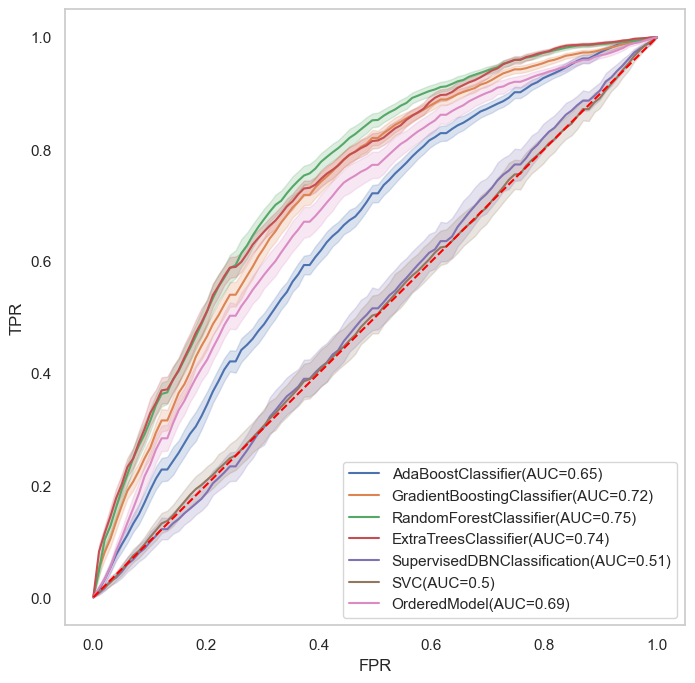

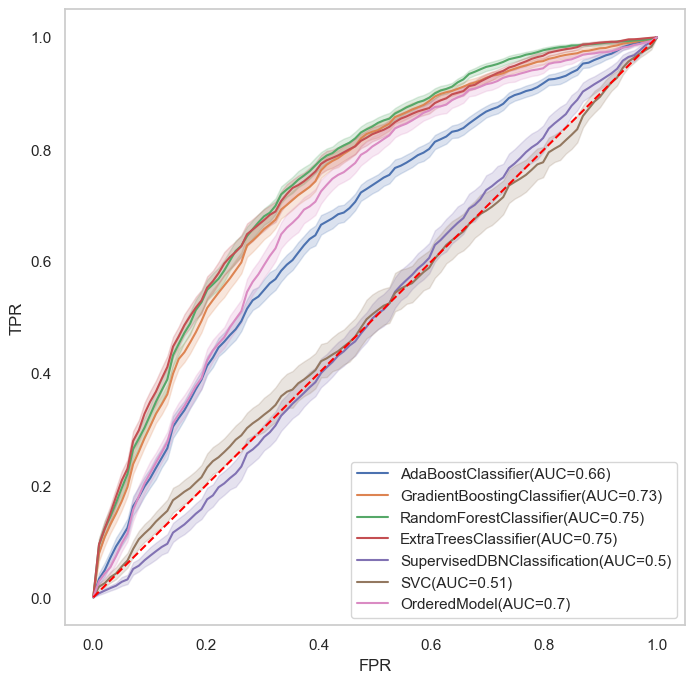

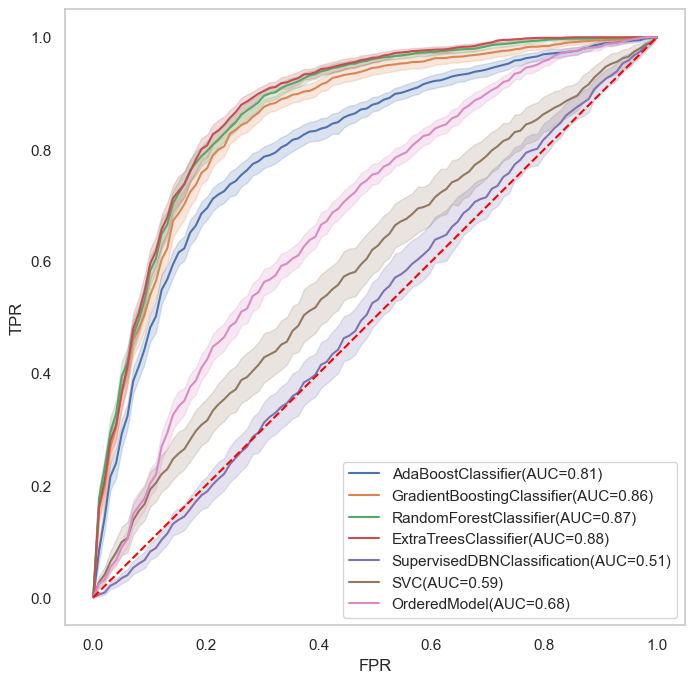

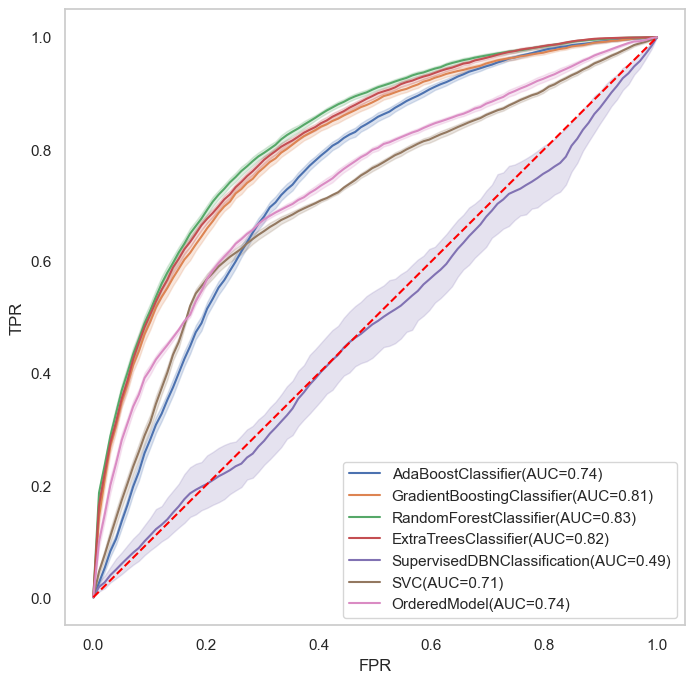

In [5]:
plot(without_MHT_roc, '../output/without_MHT')

In [6]:
def read_accuracy(dir_path: str):
    acc = {}
    for target in ['minor', 'important', 'full', 'all']:
        acc[target] = pd.read_csv(os.path.join(dir_path, 'accuracy_{}.csv'.format(target)), index_col=0)
    return acc

without_MHT_acc = read_accuracy('../output/without_MHT')

In [7]:
def get_comprehensive_comparison(acc, roc):
    acc_result = pd.DataFrame()
    for target in ['minor', 'important', 'full', 'all']:
        _acc = pd.DataFrame(acc[target].mean(), columns=[target])
        _acc = (round(_acc * 100, 2)).astype(str)
        _acc[target] += '±' + (round(acc[target].std() * 100, 2)).astype(str)
        acc_result = pd.concat([acc_result, _acc], axis=1)
    acc_result.columns = pd.MultiIndex.from_product([['Accuracy(%)'], acc_result.columns])

    roc_auc_result = pd.DataFrame()
    for target in ['minor', 'important', 'full', 'all']:
        _roc = roc[target].item()
        _roc_auc = [
            roc[target].item()[key][2]
            for key in _roc.keys()
        ]
        _roc_auc = pd.DataFrame(_roc_auc, index=_roc.keys())
        _auc = pd.DataFrame(_roc_auc.mean(axis=1), columns=[target])
        _auc = (round(_auc, 2)).astype(str)
        _auc[target] += '±' + (round(_roc_auc.std(axis=1), 2)).astype(str)
        roc_auc_result = pd.concat([roc_auc_result, _auc], axis=1)
    roc_auc_result.columns = pd.MultiIndex.from_product([['ROC-AUC'], roc_auc_result.columns])

    comprehensive_result = pd.concat([acc_result, roc_auc_result], axis=1)
    return comprehensive_result

In [8]:
comprehensive_result = get_comprehensive_comparison(without_MHT_acc, without_MHT_roc)
comprehensive_result.to_csv('../output/without_MHT/comprehensive_comparison.csv')
comprehensive_result

Accuracy(%)                            \
                                  minor    important         full   
AdaBoostClassifier           60.66±3.15   64.88±2.62   80.91±2.27   
GradientBoostingClassifier    66.84±3.2   69.36±2.52   82.34±2.44   
RandomForestClassifier       68.84±3.13   70.33±2.28   82.84±1.98   
ExtraTreesClassifier          67.52±2.8   70.67±2.64   83.04±1.92   
SupervisedDBNClassification   49.97±0.7  49.17±13.17  51.04±28.79   
SVC                          53.92±3.93   52.04±6.19  52.41±12.43   
OrderedModel                   64.5±4.8   64.74±2.33   78.72±0.63   

                                            ROC-AUC                        \
                                     all      minor  important       full   
AdaBoostClassifier            48.39±4.13  0.65±0.03  0.66±0.03  0.81±0.04   
GradientBoostingClassifier    57.01±3.33  0.72±0.03  0.73±0.03  0.86±0.03   
RandomForestClassifier        58.22±2.64  0.75±0.03  0.75±0.03  0.87±0.02   
ExtraTreesClassifier          57.51±2.33  0.74±0.03  0.75±0.03  0.88±0.02   
SupervisedDBNClassification  24.94±15.61  0.51±0.08   0.5±0.06  0.51±0.09   
SVC                           35.77±5.38   0.5±0.08  0.51±0.08  0.59±0.11   
OrderedModel                  49.87±1.13  0.69±0.05   0.7±0.04  0.68±0.04   

                                        
                                   all  
AdaBoostClassifier           0.74±0.02  
GradientBoostingClassifier   0.81±0.02  
RandomForestClassifier       0.83±0.01  
ExtraTreesClassifier         0.82±0.01  
SupervisedDBNClassification  0.49±0.13  
SVC                          0.71±0.01  
OrderedModel                 0.74±0.01